<a href="https://colab.research.google.com/github/mbenedicto99/Python4DataScience/blob/master/POC_Modelos_de_RNA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# POC RNA - Analise de modelos

## Modelo (vale para os 3 cenários)

* **Arquitetura:** MLP raso com 1 camada oculta: `Linear(in) → ReLU → Linear(out)`.

  * A **ReLU** cria não-linearidades, permitindo fronteiras/curvas complexas mesmo com uma única camada oculta.
* **Otimizador:** Adam (passo fixo), treino “full-batch” por algumas centenas de épocas (didático).
* **Sem ativação explícita na última camada**: entregamos **logits** e deixamos a função de perda aplicar a transformação apropriada (sigmoid/softmax) de forma estável.

## 1) Classificação binária

* **Dados:** 2D (ex.: `make_moons`), duas classes (0/1).
* **Saída do modelo:** 1 logit (número real sem limites).
* **Perda:** `BCEWithLogitsLoss` (combina sigmoid + entropia cruzada com estabilidade numérica).
* **Como interpretar a saída:**

  * Durante o treino, o loss recebe logits e internamente aplica **σ(z)** (sigmoid).
  * Em inferência/plot, aplicamos `torch.sigmoid(logit)` → **probabilidade da classe 1**.
* **O que o gráfico mostra (painel binário):**

  * Fundo em tons contínuos (contourf) = **P(y=1|x)**. Tons altos → mais de 50% de chance de classe 1.
  * Pontos coloridos = rótulos reais. A **fronteira de decisão** é onde P≈0.5.
* **Armadilhas/contrapontos:**

  * **Dados desbalanceados:** probabilidade pode ficar “puxada” pela classe majoritária; ajustar limiar, class weights ou métricas (ROC-AUC, F1) é importante.
  * **Calibração:** saídas não são necessariamente bem calibradas; para decisões de risco, usar Platt/Isotonic Calibration.
  * Evite duplicar ativações: **não** colocar Sigmoid na camada final **e** usar `BCEWithLogitsLoss`.

## 2) Classificação multiclasse

* **Dados:** 2D (ex.: `make_blobs`) com K=3 classes.
* **Saída do modelo:** vetor de K logits.
* **Perda:** `CrossEntropyLoss` (aplica softmax internamente aos logits).
* **Como interpretar a saída:**

  * O argmax dos logits (ou de `softmax(logits)`) dá a **classe predita**.
  * `softmax(logits)` fornece uma **distribuição de probabilidade** (soma=1) por classe.
* **O que o gráfico mostra (painel multiclasse):**

  * Fundo com **regiões de classe** (cores sólidas) = argmax do softmax em cada ponto do plano.
  * Pontos coloridos = rótulos reais; sobreposição entre pontos e regiões indica acerto/erro visualmente.
* **Armadilhas/contrapontos:**

  * **Classes desbalanceadas** ou com **dispersões diferentes** pedem métricas como macro-F1 e/ou pesos na perda.
  * **Margens de decisão** podem ficar irregulares se o hidden for pequeno; aumentar neurônios, regularizar (peso L2, dropout) ou normalizar entradas ajuda.

## 3) Regressão (valor real)

* **Dados:** 1D (ex.: `y = sin(x) + ruído`).
* **Saída do modelo:** 1 logit (interpretado como valor previsto **sem ativação**; saída linear).
* **Perda:** `MSELoss`.
* **Como interpretar a saída:**

  * A predição é um **valor contínuo**; o MLP aproxima a curva alvo via ReLU no miolo.
* **O que o gráfico mostra (painel regressão):**

  * **Pontos** = amostras com ruído.
  * **Linha** = função aprendida pelo MLP; a suavidade e aderência indicam viés/variância do modelo.
* **Armadilhas/contrapontos:**

  * **Extrapolação:** fora do intervalo visto no treino, a ReLU tende a comportamentos quase lineares → incerteza alta; considere intervalos de confiança ou modelos com conhecimento prévio.
  * **Overfitting:** com hidden grande e poucas amostras, a curva “persegue o ruído”; use validação, early stopping e regularização.

## Por que 1 camada oculta funciona?

* Um MLP com ativação não linear (ReLU/tanh) é um **aproximador universal**: com unidades suficientes, aproxima qualquer função contínua em um compacto.
* Na prática, há **trade-offs** entre capacidade (nº de neurônios), dados disponíveis, regularização e tempo de treino.

## Como ler rapidamente os três painéis

* **Esquerda (binária):** mapa de probabilidades; fronteira ≈ 0.5. Pense em **risco** e **limiar** de decisão.
* **Centro (multiclasse):** mosaico de regiões; quanto mais limpa a separação vs. pontos, melhor a **acurácia visual**.
* **Direita (regressão):** curva aprendida vs. dados; avalie **tendência**, **viés** (subajuste) e **oscilações** (superajuste).

## Suposições e testes ao seu raciocínio

* **Suposição comum:** “probabilidade = confiança calibrada”. Nem sempre; **calibração** pode ser necessária.
* **Suposição comum:** “mesmo hidden serve para tudo”. Não: tarefas pedem larguras/épocas diferentes; valide e faça **tuning** mínimo.
* **Teste crítico:** compare não só perda/accuracy; para classificação use **matriz de confusão, ROC/PR**, para regressão **RMSE/MAE** e análise de resíduos.

## Extensões práticas

* **Regularização:** L2/weight decay, dropout.
* **Ativações alternativas:** Leaky ReLU/GELU (mitigar “dying ReLU”).
* **Otimização:** learning-rate schedule, early stopping.
* **Incerteza:** ensembles ou MC-Dropout para intervalos/credibilidade em regressão e detecção de baixa confiança em classificação.

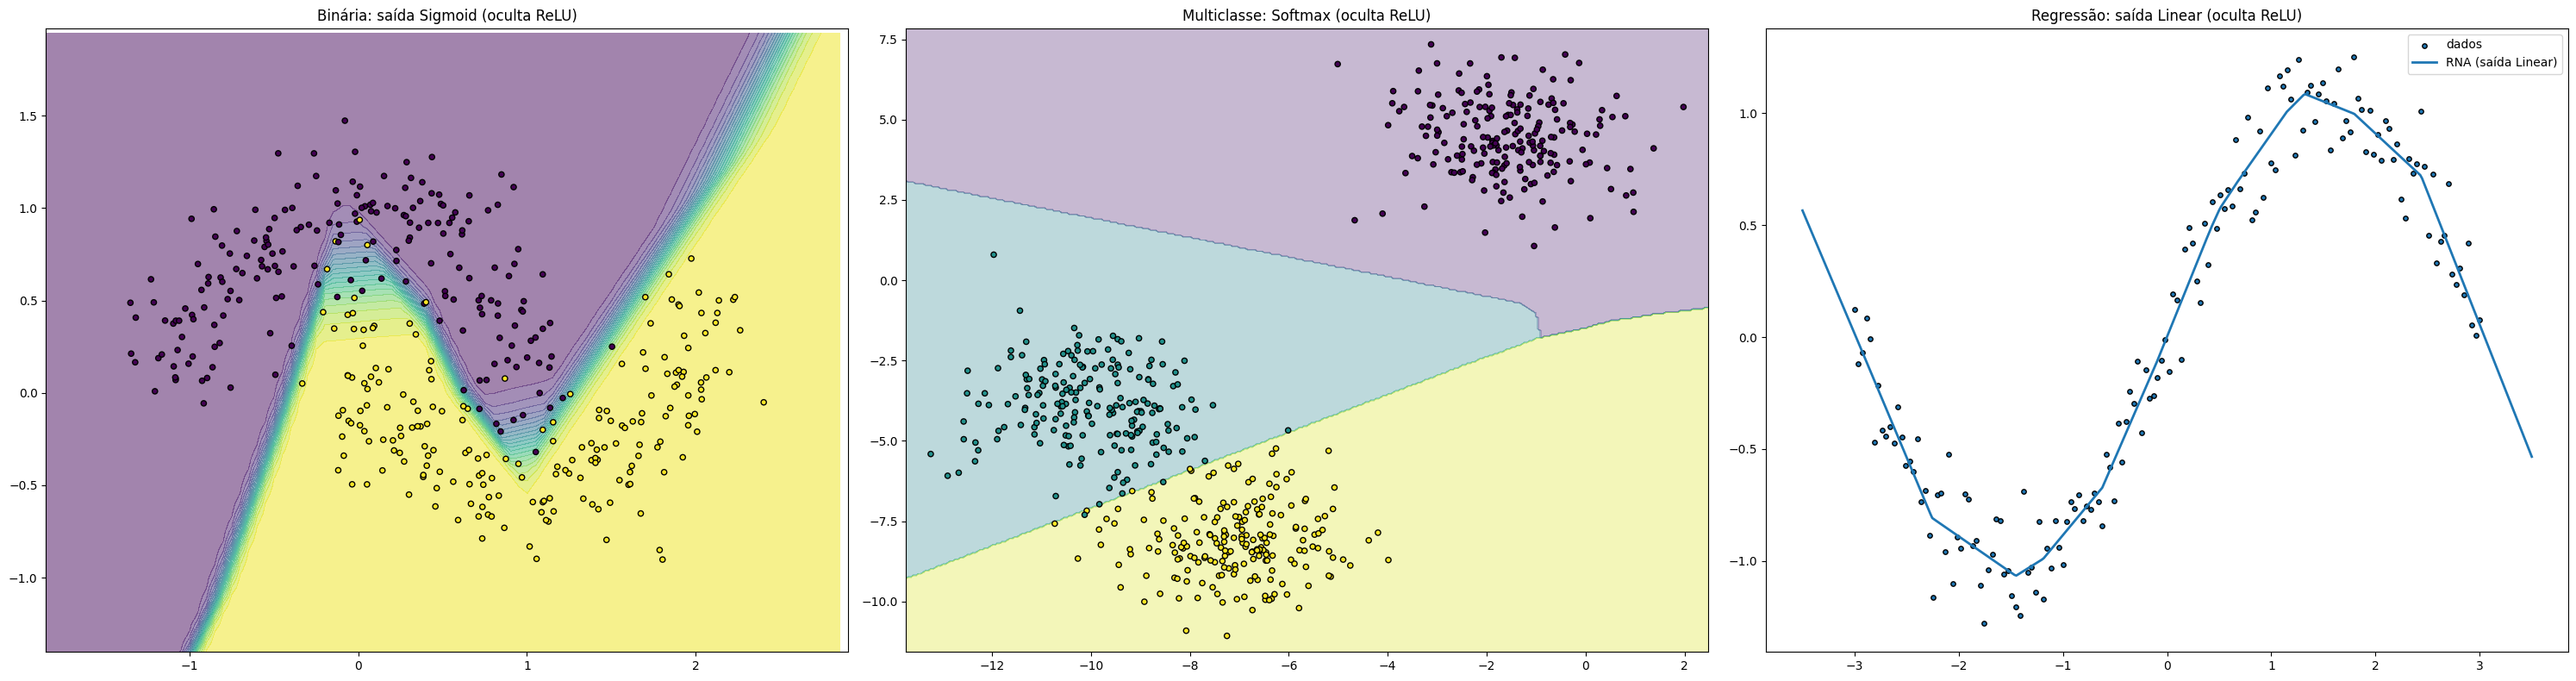

In [3]:
# -*- coding: utf-8 -*-
# Requer: python -m pip install torch scikit-learn matplotlib
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs

torch.manual_seed(0)
np.random.seed(0)
device = "cpu"

# ======= MLP simples (1 camada oculta + ReLU) =======
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.f(x)

# ======= Treino rápido (full-batch) =======
def treinar(model, X, y, loss_fn, epochs=800, lr=0.03):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        yhat = model(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

# ======= Plot de fronteira de decisão (2D) =======
def plot_decision_boundary(ax, model, X_np, y_np, task, h=0.05):
    x_min, x_max = X_np[:,0].min()-0.5, X_np[:,0].max()+0.5
    y_min, y_max = X_np[:,1].min()-0.5, X_np[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        logits = model(grid).cpu()
        if task == "bin":
            Z = torch.sigmoid(logits).reshape(xx.shape).numpy()
            cs = ax.contourf(xx, yy, Z, levels=20, alpha=0.5)
        else:
            Z = torch.softmax(logits, dim=1).argmax(1).reshape(xx.shape).numpy()
            cs = ax.contourf(xx, yy, Z, alpha=0.3)
    sc = ax.scatter(X_np[:,0], X_np[:,1], c=y_np, s=20, edgecolor="k")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# =========================
# 1) CLASSIFICAÇÃO BINÁRIA
# =========================
Xb, yb = make_moons(n_samples=400, noise=0.20, random_state=0)
Xb_t = torch.from_numpy(Xb).float().to(device)
yb_t = torch.from_numpy(yb.reshape(-1,1)).float().to(device)  # BCEWithLogitsLoss

model_bin = MLP(in_dim=2, hidden=16, out_dim=1).to(device)
loss_bin  = nn.BCEWithLogitsLoss()
treinar(model_bin, Xb_t, yb_t, loss_bin, epochs=800, lr=0.03)

# =========================
# 2) CLASSIFICAÇÃO MULTICLASSE
# =========================
Xm, ym = make_blobs(n_samples=600, centers=3, cluster_std=1.2, random_state=1)
Xm_t = torch.from_numpy(Xm).float().to(device)
ym_t = torch.from_numpy(ym).long().to(device)  # CrossEntropyLoss espera classes 0..K-1

model_multi = MLP(in_dim=2, hidden=16, out_dim=3).to(device)
loss_multi  = nn.CrossEntropyLoss()
treinar(model_multi, Xm_t, ym_t, loss_multi, epochs=800, lr=0.03)

# =========================
# 3) REGRESSÃO (1D)
# =========================
n = 160
xr = np.linspace(-3, 3, n).reshape(-1,1)
yr = np.sin(xr) + 0.15*np.random.randn(n,1)

xr_t = torch.from_numpy(xr).float().to(device)
yr_t = torch.from_numpy(yr).float().to(device)

model_reg = MLP(in_dim=1, hidden=32, out_dim=1).to(device)
loss_reg  = nn.MSELoss()
treinar(model_reg, xr_t, yr_t, loss_reg, epochs=1200, lr=0.02)

# Predição suave para visualização
xgrid = np.linspace(-3.5, 3.5, 400).reshape(-1,1)
with torch.no_grad():
    ypred = model_reg(torch.from_numpy(xgrid).float().to(device)).cpu().numpy()

# ======= PLOTS LADO A LADO =======
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# Binária
plot_decision_boundary(axes[0], model_bin, Xb, yb, task="bin")
axes[0].set_title("Binária: saída Sigmoid (oculta ReLU)")

# Multiclasse
plot_decision_boundary(axes[1], model_multi, Xm, ym, task="multi")
axes[1].set_title("Multiclasse: Softmax (oculta ReLU)")

# Regressão
axes[2].scatter(xr, yr, s=15, edgecolor="k", label="dados")
axes[2].plot(xgrid, ypred, linewidth=2, label="RNA (saída Linear)")
axes[2].set_title("Regressão: saída Linear (oculta ReLU)")
axes[2].legend()

plt.tight_layout()
plt.show()

# Objetivo do script

Demonstrar, de forma comparável, três tarefas clássicas com um **mesmo MLP raso** (1 camada oculta com ReLU):

1. **Classificação binária** (saída sigmoid via `BCEWithLogitsLoss`);
2. **Classificação multiclasse** (softmax implícito via `CrossEntropyLoss`);
3. **Regressão** (saída linear com `MSELoss`).

O script imprime **métricas numéricas** (Accuracy/F1 para classificação; RMSE/MAE para regressão) e exibe **3 gráficos lado a lado**: duas “fronteiras de decisão” (binária e multiclasse) e uma curva estimada (regressão).

---

## Organização geral

* **Seeds** (`torch.manual_seed`, `np.random.seed`): tornam o resultado reprodutível.
* **Geradores de dados sintéticos**

  * Binária: `make_moons` (duas luas entrelaçadas, problema não linear).
  * Multiclasse: `make_blobs` (3 centros com dispersão).
  * Regressão: `y = sin(x) + ruído`.
* **Split treino/teste** com `train_test_split` (estratificado nas tarefas de classificação).
* **Modelo comum** (`MLP`): `Linear(in) → ReLU → Linear(out)`.
  A camada oculta ReLU fornece a não-linearidade necessária para fronteiras/curvas não triviais.
* **Treinador**: laço simples com Adam, sem regularização (didático e direto).
* **Plots**:

  * Binária / Multiclasse: malha 2D + `contourf` de probabilidades/regiões.
  * Regressão: dispersão (teste) + linha com predição suave no contínuo.

---

## Funções de perda e **interpretação da saída**

* **Binária**

  * **Saída do modelo**: 1 **logit** (número real).
  * **Perda**: `BCEWithLogitsLoss` (combina sigmoid + entropia cruzada de modo estável).
  * **Inferência**: aplica-se `sigmoid(logit)` para obter **P(classe=1)**; o script usa limiar 0,5 para classificar 0/1.
* **Multiclasse (K=3)**

  * **Saída do modelo**: vetor de **K logits**.
  * **Perda**: `CrossEntropyLoss` (aplica softmax internamente).
  * **Inferência**: `argmax(logits)` → classe predita. Se quiser probabilidades, use `softmax(logits, dim=1)`.
* **Regressão**

  * **Saída do modelo**: 1 valor **linear** (sem ativação final).
  * **Perda**: `MSELoss` (média do erro quadrático).

Por que “logits sem ativação final” no forward? Porque as perdas (`BCEWithLogitsLoss`/`CrossEntropyLoss`) **esperam** logits e **fazem** as transformações internamente, com melhor estabilidade numérica (evita under/overflow).

---

## Métricas impressas (e por que elas)

* **Binária**:

  * **Accuracy**: fração de acertos.
  * **F1**: média harmônica de precisão e revocação — mais informativa quando há **desbalanceamento**.
* **Multiclasse**:

  * **Accuracy**: acertos totais/total.
  * **F1 (macro)**: F1 por classe e média simples (cada classe pesa igual, útil se distribuições são diferentes).
* **Regressão**:

  * **RMSE** (raiz do MSE): penaliza erros grandes; tem mesma unidade do alvo.
  * **MAE**: erro absoluto médio; mais robusto a outliers.

Em todos os casos, as métricas são calculadas **no conjunto de teste** (generalização).

---

## O que os gráficos mostram

* **Painel binário (esquerda)**:

  * Fundo (contínuo) = **P(y=1|x)**; a **fronteira de decisão** é ≈ linha onde P=0,5.
  * Pontos = amostras de **teste** com rótulo real (cores).
* **Painel multiclasse (centro)**:

  * Fundo (regiões) = **classe de maior probabilidade** (argmax do softmax implícito).
  * Pontos = teste; sobreposição com a região indica acerto/erro visualmente.
* **Painel regressão (direita)**:

  * Pontos = pares (x,y) de **teste**.
  * Linha = **função aprendida** pelo MLP ao longo de um grid mais denso; observe suavidade e aderência.

Detalhe: a malha 2D usa passo `h=0.05`. Menor `h` = fronteira mais “lisa” (e mais custo de renderização).

---

## Decisões de modelagem (e seus porquês)

* **1 camada oculta ReLU**: suficiente para aprender separações não lineares simples; mantém o foco na **diferença de cabeçalhos de saída** (sigmoid/softmax/linear) em vez de profundidade de rede.
* **Adam** com `lr` fixo: converge rápido nos problemas sintéticos; simplifica o exemplo.
* **Sem padronização de features**: como os dados 2D já nascem “bem comportados”, a omissão facilita a didática. Em dados reais, **normalizar** quase sempre ajuda.
* **Sem regularização/early stopping**: propositais para reduzir distrações. Em produção, são essenciais.

---

## Leitura crítica: suposições & testes

* **Suposição 1**: *“Limiar 0,5 é adequado na binária.”*
  Nem sempre. Se as classes forem desbalanceadas ou o custo de falsos positivos/negativos for assimétrico, **tune o limiar** com ROC/PR ou maximize F1/Youden.
* **Suposição 2**: *“Accuracy representa bem a qualidade.”*
  Para dados desbalanceados, prefira **F1**, **ROC-AUC** e **PR-AUC**.
* **Suposição 3**: *“Mesmo hidden serve para tudo.”*
  Tamanho da camada, épocas e `lr` **importam**. Faça validação simples para ajustar.
* **Suposição 4**: *“Probabilidade = confiança calibrada.”*
  Nem sempre. Para decisões críticas, avalie **calibração** (Platt/Isotonic).

**Testes práticos** que validam (ou derrubam) as suposições:

* Curvas ROC/PR e matriz de confusão (binária/multiclasse).
* Learning curves (perda treino vs validação).
* Sensibilidade ao `hidden`, `lr`, épocas e ruído dos dados.
* Para regressão: análise de **resíduos** (heteroscedasticidade, viés local).

---

## Limitações importantes (e como mitigar)

* **Overfitting** (especialmente na regressão com hidden maior): usar validação, **early stopping**, **weight decay** e, se preciso, **dropout**.
* **Extrapolação** (regressão): fora do domínio visto, a rede ReLU tende ao **quase linear**; explicite incerteza (intervalos), adote ensembles/MC-Dropout ou imponha estrutura (features engenharia, bases de funções).
* **Escala das features**: em dados reais, **padronize** (`StandardScaler`), principalmente para problemas com faixa de valores distinta.
* **Interpretabilidade**: fronteiras/curva dão um “feeling” visual, mas para produção considere **SHAP/permutações** e checagens de drift.

---

## Extensões rápidas (se for evoluir o notebook)

* **Métricas extras**: ROC-AUC/PR-AUC (binária), matriz de confusão, classificação top-k (multiclasse); R² e gráficos de resíduos (regressão).
* **Regularização**: `weight_decay` no Adam e/ou `Dropout` na oculta.
* **Normalização**: `StandardScaler` para X (2D) e talvez `MinMaxScaler` para x na regressão.
* **Scheduler**: `torch.optim.lr_scheduler` (ex.: `CosineAnnealingLR`).
* **Calibração**: `sklearn.calibration` (binária/multiclasse).

---

## Como encaixar no seu notebook

* **Célula 1**: imports + seeds + definição do `MLP`, `treinar` e `plot_decision_boundary`.
* **Célula 2**: bloco **binária** (dados, treino, métricas, nada de plot ainda).
* **Célula 3**: bloco **multiclasse** (idem).
* **Célula 4**: bloco **regressão** (idem).
* **Célula 5**: criação dos **3 subplots** lado a lado (usando os modelos já treinados) e `plt.show()`.

Assim você pode reexecutar apenas a parte que quer iterar (ex.: trocar `hidden`, `epochs`, ruído, etc.) sem repetir tudo.

---

### Em uma frase

O script é um **laboratório mínimo e honesto** para ver, lado a lado, como **a mesma arquitetura** (ReLU na oculta) se comporta quando você muda **apenas a cabeça de saída** e a **função de perda** — e como isso se traduz em **probabilidades/regiões** (classificação) vs **curvas contínuas** (regressão), com métricas de **generalização** para cada caso.

=== Classificação Binária ===
Acurácia: 0.911 | F1: 0.912

=== Classificação Multiclasse ===
Acurácia: 0.993 | F1 (macro): 0.993

=== Regressão ===
RMSE: 0.171 | MAE: 0.143


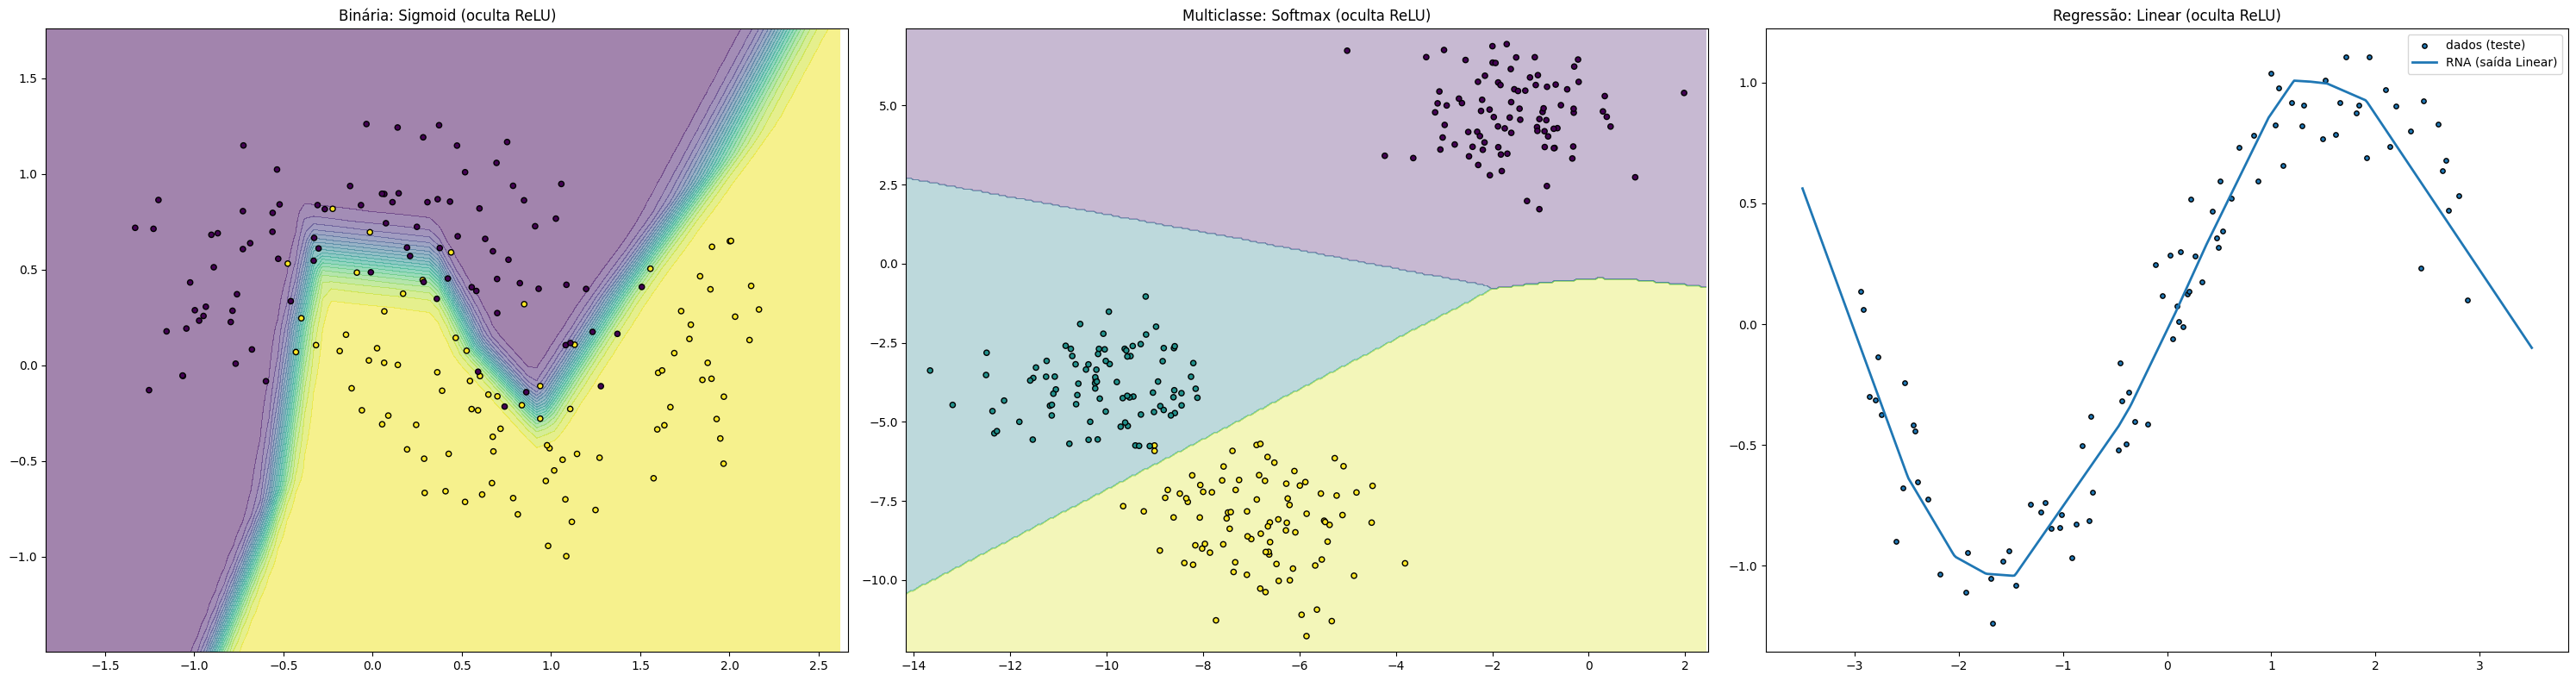

In [7]:
# -*- coding: utf-8 -*-
# Dependências: python -m pip install torch scikit-learn matplotlib
import numpy as np
import torch, torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, mean_squared_error, mean_absolute_error

torch.manual_seed(0)
np.random.seed(0)
device = "cpu"

# ---------- MLP simples: 1 oculta (ReLU) ----------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden, out_dim):
        super().__init__()
        self.f = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_dim)
        )
    def forward(self, x):
        return self.f(x)

def treinar(model, X, y, loss_fn, epochs=600, lr=0.03):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(epochs):
        opt.zero_grad()
        yhat = model(X)
        loss = loss_fn(yhat, y)
        loss.backward()
        opt.step()

def plot_decision_boundary(ax, model, X_np, y_np, task, h=0.05):
    x_min, x_max = X_np[:,0].min()-0.5, X_np[:,0].max()+0.5
    y_min, y_max = X_np[:,1].min()-0.5, X_np[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()
    with torch.no_grad():
        logits = model(grid).cpu()
        if task == "bin":
            Z = torch.sigmoid(logits).reshape(xx.shape).numpy()
            ax.contourf(xx, yy, Z, levels=20, alpha=0.5)
        else:
            Z = torch.softmax(logits, dim=1).argmax(1).reshape(xx.shape).numpy()
            ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_np[:,0], X_np[:,1], c=y_np, s=20, edgecolor="k")
    ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)

# =========================
# 1) CLASSIFICAÇÃO BINÁRIA
# =========================
Xb, yb = make_moons(n_samples=600, noise=0.25, random_state=0)
Xb_tr, Xb_te, yb_tr, yb_te = train_test_split(Xb, yb, test_size=0.30, random_state=0, stratify=yb)

Xb_tr_t = torch.from_numpy(Xb_tr).float().to(device)
yb_tr_t = torch.from_numpy(yb_tr.reshape(-1,1)).float().to(device)
Xb_te_t = torch.from_numpy(Xb_te).float().to(device)
yb_te_t = torch.from_numpy(yb_te.reshape(-1,1)).float().to(device)

model_bin = MLP(in_dim=2, hidden=16, out_dim=1).to(device)
loss_bin  = nn.BCEWithLogitsLoss()
treinar(model_bin, Xb_tr_t, yb_tr_t, loss_bin, epochs=700, lr=0.03)

with torch.no_grad():
    logits_te = model_bin(Xb_te_t).cpu().numpy()
    prob_te   = 1/(1+np.exp(-logits_te))
    ypred_bin = (prob_te >= 0.5).astype(int).ravel()

acc_bin = accuracy_score(yb_te, ypred_bin)
f1_bin  = f1_score(yb_te, ypred_bin)

print("=== Classificação Binária ===")
print(f"Acurácia: {acc_bin:.3f} | F1: {f1_bin:.3f}")

# =========================
# 2) CLASSIFICAÇÃO MULTICLASSE
# =========================
Xm, ym = make_blobs(n_samples=900, centers=3, cluster_std=1.2, random_state=1)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.30, random_state=1, stratify=ym)

Xm_tr_t = torch.from_numpy(Xm_tr).float().to(device)
ym_tr_t = torch.from_numpy(ym_tr).long().to(device)
Xm_te_t = torch.from_numpy(Xm_te).float().to(device)
ym_te_t = torch.from_numpy(ym_te).long().to(device)

model_multi = MLP(in_dim=2, hidden=16, out_dim=3).to(device)
loss_multi  = nn.CrossEntropyLoss()
treinar(model_multi, Xm_tr_t, ym_tr_t, loss_multi, epochs=700, lr=0.03)

with torch.no_grad():
    logits_te = model_multi(Xm_te_t).cpu()
    ypred_multi = torch.argmax(logits_te, dim=1).numpy()

acc_multi = accuracy_score(ym_te, ypred_multi)
f1_multi  = f1_score(ym_te, ypred_multi, average="macro")

print("\n=== Classificação Multiclasse ===")
print(f"Acurácia: {acc_multi:.3f} | F1 (macro): {f1_multi:.3f}")

# =========================
# 3) REGRESSÃO (valor real)
# =========================
n = 300
xr = np.linspace(-3, 3, n).reshape(-1,1)
yr = np.sin(xr) + 0.15*np.random.randn(n,1)
xr_tr, xr_te, yr_tr, yr_te = train_test_split(xr, yr, test_size=0.30, random_state=2)

xr_tr_t = torch.from_numpy(xr_tr).float().to(device)
yr_tr_t = torch.from_numpy(yr_tr).float().to(device)
xr_te_t = torch.from_numpy(xr_te).float().to(device)
yr_te_t = torch.from_numpy(yr_te).float().to(device)

model_reg = MLP(in_dim=1, hidden=32, out_dim=1).to(device)
loss_reg  = nn.MSELoss()
treinar(model_reg, xr_tr_t, yr_tr_t, loss_reg, epochs=1000, lr=0.02)

with torch.no_grad():
    ypred_te = model_reg(xr_te_t).cpu().numpy()

mse = mean_squared_error(yr_te, ypred_te)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yr_te, ypred_te)

print("\n=== Regressão ===")
print(f"RMSE: {rmse:.3f} | MAE: {mae:.3f}")

# ---------- Plots lado a lado ----------
fig, axes = plt.subplots(1, 3, figsize=(30, 8))

# Binária (usa conjunto de teste na dispersão)
plot_decision_boundary(axes[0], model_bin, Xb_te, yb_te, task="bin")
axes[0].set_title("Binária: Sigmoid (oculta ReLU)")

# Multiclasse
plot_decision_boundary(axes[1], model_multi, Xm_te, ym_te, task="multi")
axes[1].set_title("Multiclasse: Softmax (oculta ReLU)")

# Regressão
xgrid = np.linspace(-3.5, 3.5, 400).reshape(-1,1)
with torch.no_grad():
    ygrid = model_reg(torch.from_numpy(xgrid).float()).cpu().numpy()
axes[2].scatter(xr_te, yr_te, s=15, edgecolor="k", label="dados (teste)")
axes[2].plot(xgrid, ygrid, linewidth=2, label="RNA (saída Linear)")
axes[2].set_title("Regressão: Linear (oculta ReLU)")
axes[2].legend()

plt.tight_layout()
plt.show()